## A workbook with the entire CloudPredict workflow

After a recent interview, I realised I haven't pushed all of the work I've done on this package. I've also wanted to restart this project because some of the previous work had become quite messy with the data side of things, so instead of getting caught up in the messy detailss, we will start with a basic MVP! Once we have a simple working version, we will reconstruct it into parts, and optimise the workflow, to ultimately create an automated product.


Idea: Use the latest satellite cloud images (or binary masks) and neartime wind forecasts to predict where clouds will move, and the effect on solar irradiance.

Data:
1. Satellite cloud mask - https://data.eumetsat.int/product/EO:EUM:DAT:MSG:CLM (downloaded via eumdac api)
2. Wind "forecasts" - ~~for now just use the ERA5 product hosted by earthmover~~ ERA5 streaming via Copernicus Data Store (in beta and buggy...) - TODO: download the knmi NL forecasts



In [1]:
import xarray as xr
import cfgrib
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import eumdac

import json
import geopandas as gpd
import shapely
from shapely.strtree import STRtree


#from arraylake import Client # earthmover

import parcels # for cloud advection
from datetime import datetime, timedelta

## Part 0 - download the cloud file

In [2]:
# Credentials & Collection Setup
consumer_key = os.getenv('EUMDAC_CONSUMER_KEY')
consumer_secret = os.getenv('EUMDAC_CONSUMER_SECRET')
collection_id = 'EO:EUM:DAT:MSG:CLM'

save_directory = '../data/raw/'

token = eumdac.AccessToken((consumer_key, consumer_secret))
datastore = eumdac.DataStore(token)
collection = datastore.get_collection(collection_id)

# Filter by time range
# Choose a date to analyse
start_time = datetime(2026, 8, 1, 10, 0)
end_time = start_time + timedelta(minutes=1)

products = collection.search(dtstart=start_time, dtend=end_time)

for product in products:
    print(product)
    
    # Iterate through entries inside the product package
    for entry in product.entries:
        if entry.endswith('.grib2') or entry.endswith('.grb'):
            print(f"Downloading entry: {entry}")
            cloud_file_path = os.path.join(save_directory, entry)
            
            # Open and stream only the GRIB2 file entry
            with product.open(entry) as fsrc, open(cloud_file_path, "wb") as fdest:
                for chunk in iter(lambda: fsrc.read(4096), b""):
                    fdest.write(chunk)
            print(f"Saved {entry}")

MSG3-SEVI-MSGCLMK-0100-0100-20260801100000.000000000Z-NA
Saved MSG3-SEVI-MSGCLMK-0100-0100-20260801100000.000000000Z-NA.grb


## Part 1 - extract a cloud mask

In [3]:
# Load the cloud mask data from the GRIB file
cloud_mask = xr.open_dataset(cloud_file_path, engine='cfgrib')
start_time = cloud_mask.time.values
cloud_mask

<xarray.Dataset> Size: 276MB
Dimensions:    (values: 13778944)
Coordinates:
    latitude   (values) float64 110MB ...
    longitude  (values) float64 110MB ...
    time       datetime64[ns] 8B 2026-08-01T10:00:00
Dimensions without coordinates: values
Data variables:
    p260537    (values) float32 55MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             eums
    GRIB_centreDescription:  EUMETSAT Operation Centre
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             EUMETSAT Operation Centre
    history:                 2026-08-16T21:34 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
# SEVIRI full disk resolution is usually 3712x3712
ny, nx = 3712, 3712

# Reshape the data variable and coordinates
p260537_2d = cloud_mask["p260537"].values.reshape((ny, nx))
lat_2d = cloud_mask["latitude"].values.reshape((ny, nx))
lon_2d = cloud_mask["longitude"].values.reshape((ny, nx))

# Reconstruct a 2D Dataset
ds_2d = xr.Dataset(
    data_vars={"p260537": (("y", "x"), p260537_2d)},
    coords={
        "latitude": (("y", "x"), lat_2d),
        "longitude": (("y", "x"), lon_2d),
    },
    attrs=cloud_mask.attrs,
)

In [5]:
# Map to [-180, 180]
# 1. Convert longitudes > 180 to negative values (-180 to 180)
# For some reason you need to flip the longitudes and latitudes?
new_lon = -xr.where(ds_2d.longitude > 180, ds_2d.longitude - 360, ds_2d.longitude)
new_lat = -ds_2d.latitude  # Latitude remains unchanged

# 2. Reassign the modified 2D longitude array back to the dataset
ds_2d = ds_2d.assign_coords(longitude=new_lon, latitude=new_lat)

ds_2d

<xarray.Dataset> Size: 276MB
Dimensions:    (y: 3712, x: 3712)
Coordinates:
    latitude   (y, x) float64 110MB -0.0 -0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0 -0.0
    longitude  (y, x) float64 110MB -0.0 -0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0 -0.0
Dimensions without coordinates: y, x
Data variables:
    p260537    (y, x) float32 55MB 3.0 3.0 3.0 3.0 3.0 ... 3.0 3.0 3.0 3.0 3.0
Attributes:
    GRIB_edition:            2
    GRIB_centre:             eums
    GRIB_centreDescription:  EUMETSAT Operation Centre
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             EUMETSAT Operation Centre
    history:                 2026-08-16T21:34 GRIB to CDM+CF via cfgrib-0.9.1...

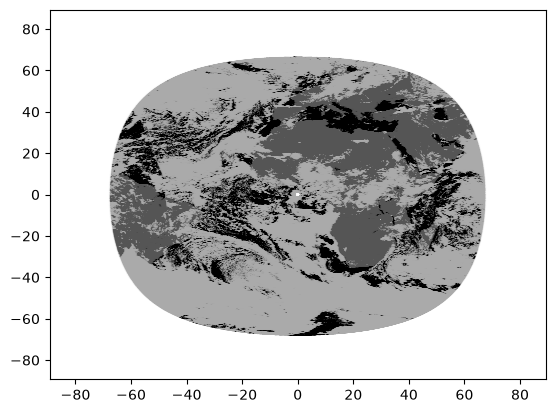

In [6]:
# Plot the entire dataset to check whether it is reasonable
# Can't pmesh because of non-monotonicity of coords
# Hack and use scatter plot instead -- this is slow...
plt.scatter(ds_2d.longitude.values.flatten(), ds_2d.latitude.values.flatten(), c=ds_2d.p260537.values.flatten(), cmap='gray', s=1)
plt.show()

In [7]:
# Subset over the Netherlands
lon_min, lon_max, lat_min, lat_max = 0, 10, 49, 56
nl_mask = (
    (ds_2d.latitude >= lat_min)
    & (ds_2d.latitude <= lat_max)
    & (ds_2d.longitude >= lon_min)
    & (ds_2d.longitude <= lon_max)
    )

# Select a bounding box and extract the NL subset
y_indices, x_indices = nl_mask.values.nonzero()
ds_2d_nl = ds_2d.isel(
    y=slice(y_indices.min(), y_indices.max() + 1),
    x=slice(x_indices.min(), x_indices.max() + 1)
    )


In [8]:
# Dataset is small enough to load into memory
ds_2d_nl.load()

<xarray.Dataset> Size: 561kB
Dimensions:    (y: 123, x: 228)
Coordinates:
    latitude   (y, x) float64 224kB 49.05 49.05 49.05 49.05 ... 56.0 56.0 56.0
    longitude  (y, x) float64 224kB 9.956 9.911 9.867 ... 0.1037 0.05185 -0.0
Dimensions without coordinates: y, x
Data variables:
    p260537    (y, x) float32 112kB 2.0 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0 2.0 2.0
Attributes:
    GRIB_edition:            2
    GRIB_centre:             eums
    GRIB_centreDescription:  EUMETSAT Operation Centre
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             EUMETSAT Operation Centre
    history:                 2026-08-16T21:34 GRIB to CDM+CF via cfgrib-0.9.1...

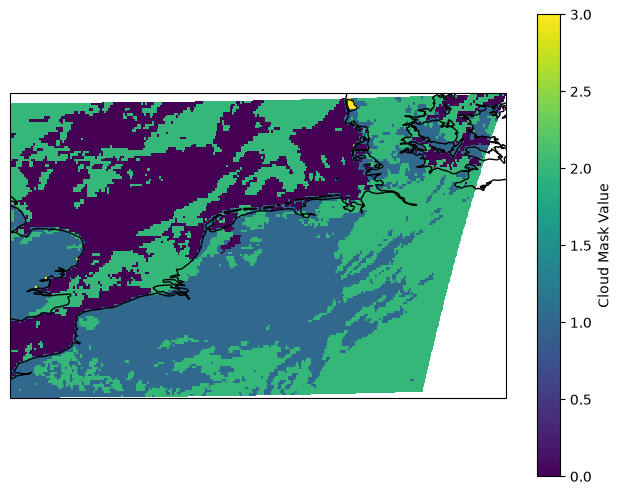

In [9]:
# Sanity check plot
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
im =ax.pcolormesh(ds_2d_nl.longitude.values, ds_2d_nl.latitude.values, ds_2d_nl.p260537.values, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label="Cloud Mask Value")
plt.show()

In [10]:
# Extract locations of cloud pixels
cloud_pixel_mask = ds_2d_nl.p260537 == 2.
cloud_lats = ds_2d_nl.latitude.values[cloud_pixel_mask.values]
cloud_lons = ds_2d_nl.longitude.values[cloud_pixel_mask.values]

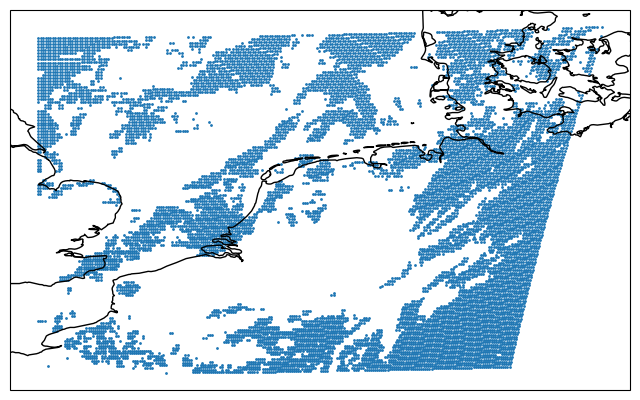

In [11]:
# Sanity check plot
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.scatter(cloud_lons, cloud_lats, transform=ccrs.PlateCarree(), s=1)

plt.show()

## Part 2 - Create the cloud simulations


In [12]:
# Surface
surface_time_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-002/arco/reanalysis_era5_single_levels/sfc/timeChunked.zarr"

# Open one of the Zarr objects with xarray, the default example opens the geo-chunked surface variables
ds_spatial = xr.open_zarr(
    surface_time_url,
    consolidated=True,
    storage_options={
        "headers": {"Authorization": f"Bearer {os.getenv('CDS_API_KEY')}"},
    }
)
ds_spatial

<xarray.Dataset> Size: 63TB
Dimensions:    (time: 759240, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2026-08-11T23:00:00
  * latitude   (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables: (12/20)
    blh        (time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    cbh        (time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    d2m        (time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    fdir       (time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    fg10       (time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    msl        (time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    ...         ...
    tcc        (time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    tp         (time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    u10        (time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    u100       (time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    v10        (time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    v100       (time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [13]:
# TODO: Find a more robust way to load the data into xarray, as sometimes the CDS gives back 403s
# # Geo-chunked data for access optimised along the time dimension (e.g. for time-series at a single point)
# surface_time_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-002/arco/reanalysis_era5_single_levels/sfc/timeChunked.zarr"
 
# # Use obstore's HTTPStore to create a store with retry configuration,
# # and then wrap it in a zarr ObjectStore to read with xarray.
# # See https://github.com/developmentseed/obstore/blob/main/obstore/python/obstore/_store/_retry.pyi
# # for more details on the retry configuration options.
# fs = fsspec.get_filesystem(
#     "https",
#     headers={"Authorization": f"Bearer {os.environ['CDS_API_KEY']}"}
# )
# store = FSStore(fs, path=surface_time_url)
# ds = xr.open_zarr(store)
# print(ds)

In [14]:
data_start_time = start_time.astype('datetime64[h]') # Round to the nearest hour for ERA5 data

# Subset to our time range (next 6 hours)
ds_spatial = ds_spatial.sel(time=slice(data_start_time, data_start_time + np.timedelta64(7, 'h')))

# Cut down our data to just the region around the Netherlands
ds_spatial = ds_spatial.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))

ds_spatial

<xarray.Dataset> Size: 762kB
Dimensions:    (time: 8, latitude: 29, longitude: 41)
Coordinates:
  * time       (time) datetime64[ns] 64B 2026-08-01T10:00:00 ... 2026-08-01T1...
  * latitude   (latitude) float64 232B 49.0 49.25 49.5 49.75 ... 55.5 55.75 56.0
  * longitude  (longitude) float64 328B 0.0 0.25 0.5 0.75 ... 9.25 9.5 9.75 10.0
Data variables: (12/20)
    blh        (time, latitude, longitude) float32 38kB dask.array<chunksize=(1, 29, 41), meta=np.ndarray>
    cbh        (time, latitude, longitude) float32 38kB dask.array<chunksize=(1, 29, 41), meta=np.ndarray>
    d2m        (time, latitude, longitude) float32 38kB dask.array<chunksize=(1, 29, 41), meta=np.ndarray>
    fdir       (time, latitude, longitude) float32 38kB dask.array<chunksize=(1, 29, 41), meta=np.ndarray>
    fg10       (time, latitude, longitude) float32 38kB dask.array<chunksize=(1, 29, 41), meta=np.ndarray>
    msl        (time, latitude, longitude) float32 38kB dask.array<chunksize=(1, 29, 41), meta=np.ndarray>
    ...         ...
    tcc        (time, latitude, longitude) float32 38kB dask.array<chunksize=(1, 29, 41), meta=np.ndarray>
    tp         (time, latitude, longitude) float32 38kB dask.array<chunksize=(1, 29, 41), meta=np.ndarray>
    u10        (time, latitude, longitude) float32 38kB dask.array<chunksize=(1, 29, 41), meta=np.ndarray>
    u100       (time, latitude, longitude) float32 38kB dask.array<chunksize=(1, 29, 41), meta=np.ndarray>
    v10        (time, latitude, longitude) float32 38kB dask.array<chunksize=(1, 29, 41), meta=np.ndarray>
    v100       (time, latitude, longitude) float32 38kB dask.array<chunksize=(1, 29, 41), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

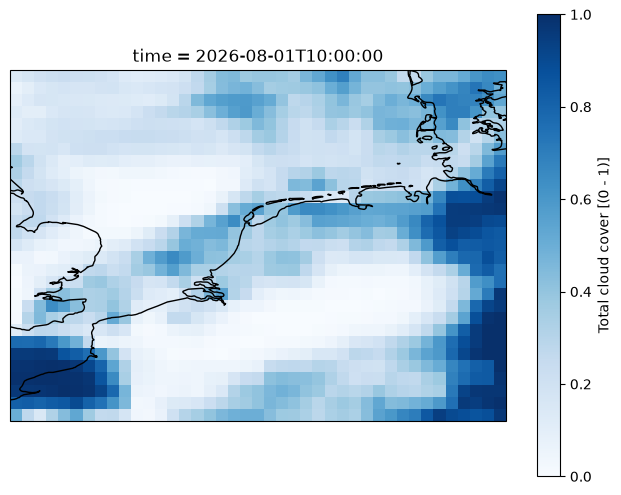

In [15]:
# Sanity check
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ds_spatial['tcc'].isel(time=0).plot(cmap='Blues', vmin=0, vmax=1)

In [16]:
# Only keep the 100m wind variables
ds_tcc = ds_spatial[["tcc"]] # Keep the total cloud cover variable for plotting
ds_spatial = ds_spatial[["u100", "v100"]]

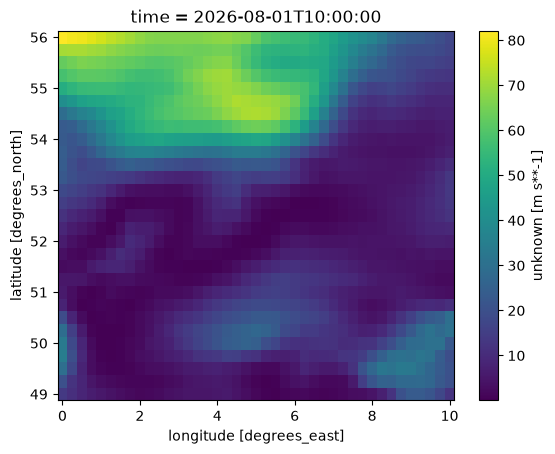

In [17]:
# Quick sanity check plot of the wind speed at the first time step
(ds_spatial.u100.isel(time=0)**2 + ds_spatial.v100.isel(time=0)**2).plot(label="squared wind speed")

In [18]:
# Construct the parcels fieldset from the wind data
variables = {"U": "u100",
            "V": "v100"}
dimensions = {"lon": "longitude",
            "lat": "latitude",
            "time": "time"}

fieldset = parcels.FieldSet.from_xarray_dataset(ds_spatial, variables, dimensions, mesh='spherical')

In [19]:
# Construct the cloud particleset
pset = parcels.ParticleSet.from_list(fieldset=fieldset, pclass=parcels.JITParticle, lon=cloud_lons, lat=cloud_lats, time=start_time)
pset

<ParticleSet>
    fieldset   :
        <FieldSet>
            fields:
                <Field>
                    name            : 'U'
                    grid            : RectilinearZGrid(lon=array([ 0.00,  0.25,  0.50, ...,  9.50,  9.75,  10.00], shape=(41,), dtype=float32), lat=array([ 49.00,  49.25,  49.50, ...,  55.50,  55.75,  56.00], shape=(29,), dtype=float32), time=array([ 0.00,  3600.00,  7200.00, ...,  18000.00,  21600.00,  25200.00], shape=(8,)), time_origin=2026-08-01T10:00:00.000000000, mesh='spherical')
                    extrapolate time: False
                    time_periodic   : False
                    gridindexingtype: 'nemo'
                    to_write        : False
                <Field>
                    name            : 'V'
                    grid            : RectilinearZGrid(lon=array([ 0.00,  0.25,  0.50, ...,  9.50,  9.75,  10.00], shape=(41,), dtype=float32), lat=array([ 49.00,  49.25,  49.50, ...,  55.50,  55.75,  56.00], shape=(29,), dtype=flo

In [20]:
def delete_particle(particle, fieldset, time):
    # Error kernel to delete particles that throw errors (e.g., out of bounds)
    if particle.state >= 50:
        particle.delete()

In [21]:

# Create an output file and run the simulation
pfile = parcels.ParticleFile("cloud_advection.zarr", pset, outputdt=timedelta(minutes=15))
pset.execute([parcels.AdvectionRK4, delete_particle], runtime=timedelta(hours=6), dt=timedelta(minutes=1), output_file=pfile)

INFO: Output files are stored in cloud_advection.zarr.
 13%|█▎        | 2760.0/21600.0 [00:03<00:19, 988.64it/s]

/Users/michael/miniconda3/envs/CloudPredict_py312/lib/python3.12/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/Users/michael/miniconda3/envs/CloudPredict_py312/lib/python3.12/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/Users/michael/miniconda3/envs/CloudPredict_py312/lib/python3.12/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


100%|██████████| 21600.0/21600.0 [00:04<00:00, 4768.68it/s] 


In [22]:
# Open the trajectory dataset
traj = xr.open_zarr("cloud_advection.zarr")

# Recreate the old plots
for obs in range(traj.obs.size):
    plt.figure(figsize=(8, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.scatter(traj.isel(obs=obs).lon.T, traj.isel(obs=obs).lat.T, transform=ccrs.PlateCarree(), s=1, c='r')

    plt.title(f"Cloud Particle Positions at {np.nanmin(traj.isel(obs=obs).time.values)}")
    plt.savefig(f"../fig/cloud_advection_{obs:02d}.png")
    plt.close('all')

    plt.figure(figsize=(8, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    #TODO: Double check this
    ds_tcc['tcc'].isel(time=obs//4).plot(cmap='Blues', vmin=0, vmax=1, ax=ax)
    ax.scatter(traj.isel(obs=obs).lon.T, traj.isel(obs=obs).lat.T, transform=ccrs.PlateCarree(), s=1, c='r')

    plt.title(f"Cloud Particle Positions (red) at {np.nanmin(traj.isel(obs=obs).time.values)}")
    plt.savefig(f"../fig/cloud_advection_tcc_{obs:02d}.png")
    plt.close('all')

In [23]:
# Create a gif of the cloud advection
import imageio
with imageio.get_writer('../fig/cloud_advection.gif', mode='I', duration=1.0, loop=0) as writer:
    for i in range(24):
        image = imageio.imread(f"../fig/cloud_advection_{i:02d}.png")
        writer.append_data(image)

with imageio.get_writer('../fig/cloud_advection_tcc.gif', mode='I', duration=1.0, loop=0) as writer:
    for i in range(24):
        image = imageio.imread(f"../fig/cloud_advection_tcc_{i:02d}.png")
        writer.append_data(image)

/var/folders/1b/nc33j7yj5cz4ggtgtq_0c86c0000gn/T/ipykernel_71599/2539441745.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(f"../fig/cloud_advection_{i:02d}.png")
/var/folders/1b/nc33j7yj5cz4ggtgtq_0c86c0000gn/T/ipykernel_71599/2539441745.py:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(f"../fig/cloud_advection_tcc_{i:02d}.png")


<img src="../fig/cloud_advection.gif" width="550" align="center">



<img src="../fig/cloud_advection_tcc.gif" width="550" align="center">

## Compare to Dutch solar farms

NOTE: Come back to looking at the geometries from the osmnx package (see commit 30f88468f16ccccbec2f911cb63570d8ce8446d3 that has the code. Have used a new approach, see below).

Dutch solarfarms map downloaded from overpass-turbo.eu, using the query:
```
overpass_query = """
    [out:json][timeout:180];
    area["ISO3166-1"="NL"]["admin_level"="2"]->.searchArea;
    (
      // Closed ways and multipolygons tagged as solar plants or generators
      way["power"="plant"]["plant:source"="solar"](area.searchArea);
      relation["power"="plant"]["plant:source"="solar"](area.searchArea);
      
      way["power"="generator"]["generator:source"="solar"](area.searchArea);
      relation["power"="generator"]["generator:source"="solar"](area.searchArea);
      
      way["landuse"="industrial"]["plant:source"="solar"](area.searchArea);
      relation["landuse"="industrial"]["plant:source"="solar"](area.searchArea);
    );
    out geom;
    """
```

In [24]:
# Load the JSON structure
with open('../data/raw/NL_solarparks.geojson', "r", encoding="utf-8") as f:
    data = json.load(f)

polygons_with_meta = []

for feature in data.get("features", []):
    # Convert the geometry dictionary back to a JSON string for shapely.from_geojson
    geom_str = json.dumps(feature["geometry"])
    geometry = shapely.from_geojson(geom_str)
    
    properties = feature.get("properties", {})
    
    polygons_with_meta.append({
        "geometry": geometry,
        "name": properties.get("name"),
        "capacity": properties.get("capacity")
    })

print(f"Processed {len(polygons_with_meta)} feature objects.")

Processed 76812 feature objects.


In [25]:
# 2. Extract geometries for the spatial index
solar_geoms = [item['geometry'] for item in polygons_with_meta]
tree = STRtree(solar_geoms)

In [26]:
# Extract last position of each cloud particle
coords = np.array([traj.isel(obs=0).lon.values, traj.isel(obs=0).lat.values]).T

# Turn it into a gpd dataframe
coords_gdf = gpd.GeoDataFrame(
    {'point_id': range(len(coords))},
    geometry=[shapely.geometry.Point(lon, lat) for lon, lat in coords],
    crs="EPSG:4326"
)

# Pretend each cloud is a circle with radius 1km
clouds_gdf = (
    coords_gdf
    .to_crs(epsg=28992)           # Project to meters
    .buffer(1000)                 # 1 km radius buffer
    .to_crs(epsg=4326)            # Project back to lon/lat
)

# Turn into a list of shapely polygons for spatial indexing
cloud_polygons = clouds_gdf.geometry.tolist()

In [27]:
# 4. Query the index
input_indices, solar_indices = tree.query(cloud_polygons, predicate="intersects")

matches = []
# 5. Access both sets of metadata using the returned indices
for input_idx, solar_idx in zip(input_indices, solar_indices):
    input_item = cloud_polygons[input_idx]
    solar_item = polygons_with_meta[solar_idx]
    
    # print(f"Match Found:")
    # print(f"  Input Polygon Index: {input_idx}")
    # print(f"  Solar Park Name: {solar_item.get('name')}")
    # print(f"  Solar Park Capacity: {solar_item.get('capacity')}")

    matches.append([input_idx, solar_idx, 0 if solar_item.get('capacity') is None else solar_item.get('capacity')])

matches = np.array(matches)

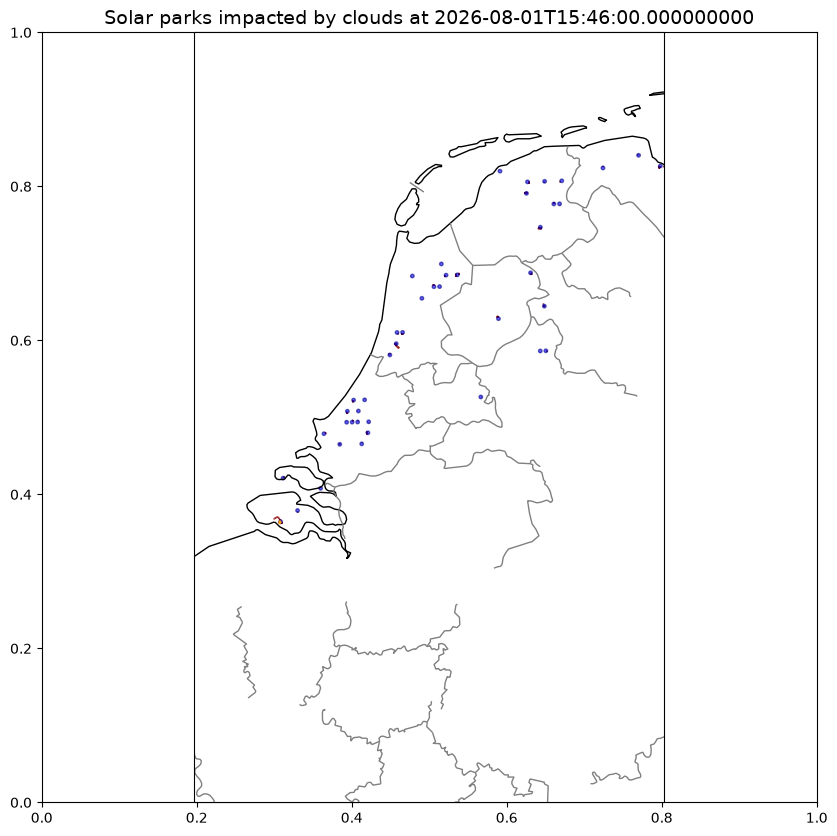

In [28]:
# Plot overlapping polygons
gdf_solar = gpd.GeoDataFrame([polygons_with_meta[i] for i in np.unique(matches[:,1])], geometry="geometry", crs="EPSG:4326")
gdf_clouds = gpd.GeoDataFrame(geometry=[cloud_polygons[i] for i in np.unique(matches[:,0])], crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
# Add some geographical context
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)
ax.coastlines(resolution='10m')
ax.add_feature(states_provinces, edgecolor='gray')


gdf_solar.plot(ax=ax, color="orange", edgecolor="darkred", alpha=0.6, transform=ccrs.PlateCarree())
gdf_clouds.plot(ax=ax, color="blue", edgecolor="darkblue", alpha=0.6, transform=ccrs.PlateCarree())

ax.set_title(f"Solar parks impacted by clouds at {np.nanmin(traj.isel(obs=-1).time.values)}", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim([3, 7])
ax.set_ylim([50, 54])

plt.show()

In [29]:
# Find the intersections as shapes
#intersections = gpd.overlay(gdf_clouds, gdf_solar, how="intersection") # Raises a NotImplementedError: df2 contains mixed geometry types.

# Clean up the solar parks to just have Polygons (no MultiPolygons) so that the overlay works
valid_mask = gdf_solar.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])
gdf_solar_polys = gdf_solar[valid_mask].copy()

# 3. Explode any MultiPolygons to single Polygons to satisfy overlay requirements
gdf_solar_clean = gdf_solar_polys.explode(index_parts=False).reset_index(drop=True)

# 4. Perform overlay (will now run without errors)
intersections = gpd.overlay(gdf_clouds, gdf_solar_clean, how="intersection")

# Reproject and extract the areas
intersections_m = intersections.to_crs(epsg=28992)
intersections["area_m2"] = intersections_m.geometry.area
intersections["area_km2"] = intersections["area_m2"] / 1000000

In [30]:
# Assuming 50MW per km² of solar park capacity
solar_generation_loss = intersections["area_km2"].sum() * 50  # MW
print(f"Estimated solar generation loss due to cloud cover: {solar_generation_loss:.2f} MW")

Estimated solar generation loss due to cloud cover: 117.35 MW


This is obviously very naive. Need to compare to solar irradiance, and where clouds were already expected to reduce solar generation!

## Compare to solar irradiance data

First need to download data from KNMI
(see commit 30f88468f16ccccbec2f911cb63570d8ce8446d3 that has the code.)